<a href="https://colab.research.google.com/github/Lio72rga/Mineria-de-Datos-2026/blob/main/Notebook_2_%E2%80%93_ID3_vs_CART_C9_LM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Centro Politécnico Superior Malvinas Argentinas
**Tecnicatura en Ciencias de Datos e Inteligencia Artificial**  
Clase 9 – Árboles de Decisión  
Notebook 2: Comparación ID3 vs CART  
Autor: Lionel Martínez  
Fecha: Junio 2026


# --- Introducción ---
# Objetivo: Comparar precisión y estructura entre ID3 y CART usando dataset de pingüinos.

# Estilo Visual

In [8]:
import seaborn as sns
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-darkgrid")


# Entrenamiento de modelos

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

df = sns.load_dataset("penguins").dropna()
X = df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tree_id3 = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42).fit(X_train, y_train)
tree_cart = DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=42).fit(X_train, y_train)


# Visualización de árboles

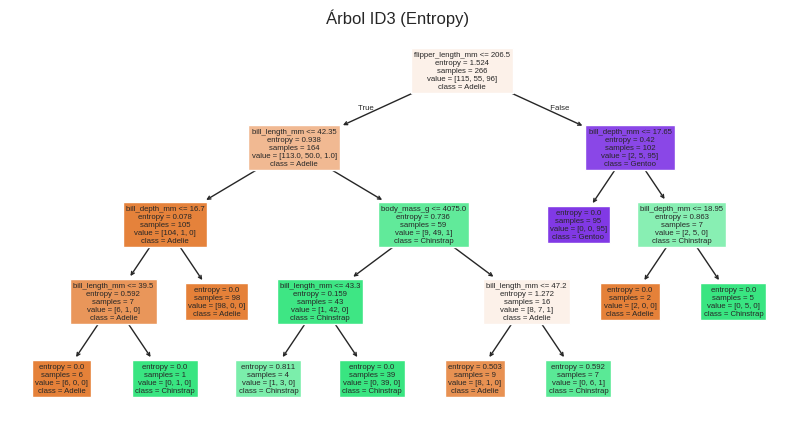

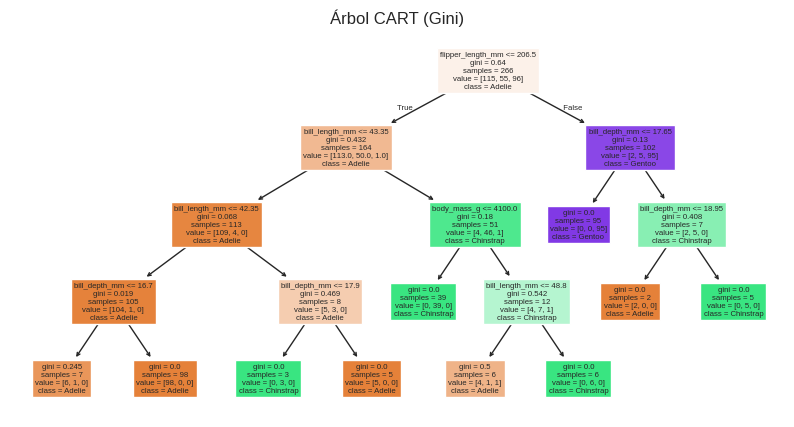

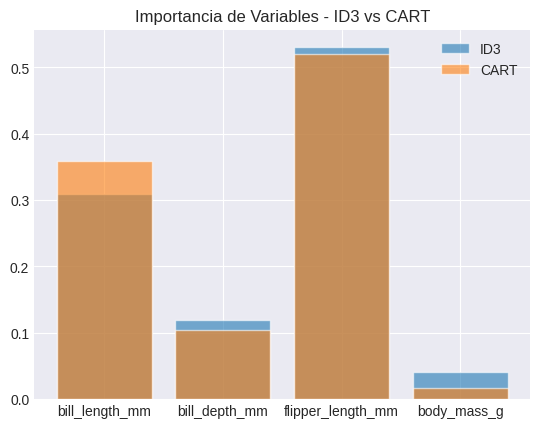

In [10]:
plt.figure(figsize=(10,5))
plot_tree(tree_id3, feature_names=X.columns, class_names=tree_id3.classes_, filled=True)
plt.title("Árbol ID3 (Entropy)")
plt.show()

plt.figure(figsize=(10,5))
plot_tree(tree_cart, feature_names=X.columns, class_names=tree_cart.classes_, filled=True)
plt.title("Árbol CART (Gini)")
plt.show()

features = X.columns
plt.bar(features, tree_id3.feature_importances_, alpha=0.6, label="ID3")
plt.bar(features, tree_cart.feature_importances_, alpha=0.6, label="CART")
plt.title("Importancia de Variables - ID3 vs CART")
plt.legend()
plt.show()


### Comparativo visual de importancia de variables


In [11]:
print("Precisión ID3:", accuracy_score(y_test, tree_id3.predict(X_test)))
print("Precisión CART:", accuracy_score(y_test, tree_cart.predict(X_test)))


Precisión ID3: 0.9850746268656716
Precisión CART: 0.9850746268656716


# Métricas y Análisis

In [12]:
from sklearn.metrics import accuracy_score

acc_id3 = accuracy_score(y_test, tree_id3.predict(X_test))
acc_cart = accuracy_score(y_test, tree_cart.predict(X_test))

print(f"Precisión ID3: {acc_id3:.2f}")
print(f"Precisión CART: {acc_cart:.2f}")


Precisión ID3: 0.99
Precisión CART: 0.99


### Análisis de resultados
Ambos algoritmos alcanzan precisiones similares, aunque CART tiende a generar árboles más compactos.
El gráfico de importancia muestra que las variables de longitud y masa son las más influyentes.
Esta comparación evidencia cómo distintos criterios de división pueden afectar la estructura del modelo.


### Conclusión
ID3 genera árboles más detallados, mientras que CART produce estructuras binarias más simples y eficientes.  
La comparación gráfica evidencia diferencias en la forma de dividir los datos y en la relevancia de las variables.  
En este dataset, la precisión depende principalmente de la profundidad máxima y del criterio de división elegido.  
Esta comparación permite comprender cómo distintos algoritmos pueden ofrecer soluciones complementarias según el contexto analítico.

